s# Prepare CAMELS Multi-Basin Transformer Data

This notebook loads CAMELS basin-mean meteorological forcing and observed streamflow, aligns them by basin and date, and writes model-ready files for training one transformer across multiple basins.

Default setup:

- Inputs: NLDAS meteorological forcing variables from `basin_timeseries_v1p2_metForcing_obsFlow.zip`.
- Target: observed streamflow from the same archive, converted to runoff depth `QObs(mm/day)` by default.
- Multi-basin support: choose any list of USGS basin IDs, or leave the list empty to use all basins with complete forcing/target pairs.
- Outputs: one flat input table, one flat target table, one joined table, and optionally one windowed `.npz` file for transformer training.

Note: the local dataset folder currently does not contain `basin_timeseries_v1p2_modelOutput_nldas.zip`. The meteorological forcing variables are already present in `basin_timeseries_v1p2_metForcing_obsFlow.zip` under `basin_mean_forcing/nldas/`.

## Dependencies

This notebook expects `pandas` and `numpy`. Parquet output also needs either `pyarrow` or `fastparquet`; if neither is installed, the notebook automatically falls back to CSV.

Install the common stack with:

```bash
pip install pandas numpy pyarrow
```

PyTorch is only needed for the optional dataset example at the end.

In [12]:
from __future__ import annotations

try:
    import io
    import json
    import math
    import re
    import zipfile
    from dataclasses import dataclass
    from pathlib import Path
    from typing import Dict, Iterable, List, Optional

    import numpy as np
    import pandas as pd
except ModuleNotFoundError as exc:
    missing = exc.name
    raise ModuleNotFoundError(
        f"Missing dependency '{missing}'. Install notebook dependencies with: "
        "pip install pandas numpy pyarrow"
    ) from exc

## Configuration

Edit this cell for the basins, forcing product, dates, target units, and output paths you want.

A few useful choices:

- `BASIN_IDS = []` uses all basins that have both forcing and streamflow files.
- `TARGET_UNIT = "mm/day"` makes targets comparable across basins by normalizing flow with drainage area.
- `TARGET_UNIT = "cfs"` keeps the raw USGS streamflow values.
- `FORCING_PRODUCT = "nldas"` is recommended here because the requested NLDAS forcing is present in the main archive.

In [20]:
import os
PDIR = os.getcwd()
DATA_DIR = os.path.join(PDIR, '..', '15529996')
TIMESERIES_ZIP = os.path.join( DATA_DIR, 'basin_timeseries_v1p2_metForcing_obsFlow.zip' )

# Optional separate sources. The notebook will use these only if they exist, are readable zip files,
# and contain the expected basin forcing layout.
MODEL_OUTPUT_NLDAS_ZIP = os.path.join( DATA_DIR, 'basin_timeseries_v1p2_modelOutput_nldas.zip' )
MODEL_OUTPUT_DAYMET_ZIP = os.path.join(DATA_DIR, 'basin_timeseries_v1p2_modelOutput_daymet.zip')

OUTPUT_DIR = os.path.join(PDIR, 'CAMELS_data_load', 'processed')
os.makedirs(OUTPUT_DIR, exist_ok=True)

FORCING_PRODUCT = 'nldas'  # preferred product; one of: nldas, daymet, maurer
ALLOW_DAYMET_MODEL_OUTPUT_FALLBACK = True
BASIN_IDS = [
    #'01013500',
    #'03366500',
]

START_DATE = '1980-01-01'
END_DATE = '2014-12-31'

TARGET_UNIT = 'mm/day'  # 'mm/day' or 'cfs'
INCLUDE_BASIN_ID_FEATURE = True
INCLUDE_DAY_OF_YEAR_FEATURES = True

# If True, create sequence windows suitable for a transformer.
BUILD_SEQUENCE_FILE = True
LOOKBACK_DAYS = 365
FORECAST_HORIZON_DAYS = 1
STRIDE_DAYS = 1

# Keep this modest for quick experimentation. Set to None to use all valid windows.
MAX_WINDOWS = None
RANDOM_SEED = 7643

## Helpers

These functions read directly from the CAMELS zip without extracting the whole archive. They are written defensively so you can swap basin selections and forcing products without touching the parsing logic.

In [27]:
@dataclass(frozen=True)
class CamelsPaths:
    forcing: Dict[str, str]
    streamflow: Dict[str, str]
    gauge_info: Optional[str]


def _normalise_basin_id(basin_id) -> str:
    return str(basin_id).strip().zfill(8)


def _is_readable_zip(path) -> bool:
    USE_MODEL_OUTPUT = False
    if not USE_MODEL_OUTPUT and "modelOutput" in str(path):
        return False
    path = Path(path)
    return path.exists() and zipfile.is_zipfile(path)


def choose_forcing_source():
    """Choose the best available forcing source and product.

    Preference order:
    1. Requested NLDAS model-output archive, if present and readable.
    2. DAYMET model-output archive, if allowed, present, and readable.
    3. Main CAMELS metForcing/obsFlow archive, which contains basin_mean_forcing.

    The local DAYMET model-output file in this workspace currently appears incomplete, so this
    function validates zip readability before choosing it.
    """
    notes = []

    if FORCING_PRODUCT == 'nldas':
        if _is_readable_zip(MODEL_OUTPUT_NLDAS_ZIP):
            return MODEL_OUTPUT_NLDAS_ZIP, 'nldas', notes
        notes.append(f'NLDAS model-output archive not readable/found: {MODEL_OUTPUT_NLDAS_ZIP}')

        if ALLOW_DAYMET_MODEL_OUTPUT_FALLBACK:
            if _is_readable_zip(MODEL_OUTPUT_DAYMET_ZIP):
                notes.append(f'Using DAYMET model-output fallback: {MODEL_OUTPUT_DAYMET_ZIP}')
                return MODEL_OUTPUT_DAYMET_ZIP, 'daymet', notes
            notes.append(f'DAYMET model-output fallback not readable/found: {MODEL_OUTPUT_DAYMET_ZIP}')

    return TIMESERIES_ZIP, FORCING_PRODUCT, notes


def index_camels_zip(zip_path: Path, forcing_product: str = 'nldas') -> CamelsPaths:
    forcing_pattern = re.compile(
        rf'basin_mean_forcing/(?:v1p15/)?{re.escape(forcing_product)}/\d{{2}}/(\d{{8}})_.*_forcing_leap\.txt$'
    )
    streamflow_pattern = re.compile(r'usgs_streamflow/\d{2}/(\d{8})_streamflow_qc\.txt$')

    forcing: Dict[str, str] = {}
    streamflow: Dict[str, str] = {}
    gauge_info = None

    with zipfile.ZipFile(zip_path) as zf:
        for name in zf.namelist():
            m = forcing_pattern.search(name)
            if m:
                # Prefer the v1p2 layout over v1p15 duplicates when both exist.
                basin_id = m.group(1)
                if basin_id not in forcing or '/v1p15/' not in name:
                    forcing[basin_id] = name
                continue

            m = streamflow_pattern.search(name)
            if m:
                streamflow[m.group(1)] = name
                continue

            if name.endswith('basin_metadata/gauge_information.txt'):
                gauge_info = name

    return CamelsPaths(forcing=forcing, streamflow=streamflow, gauge_info=gauge_info)


def read_gauge_info(zip_path: Path, gauge_info_path: Optional[str]) -> pd.DataFrame:
    if gauge_info_path is None:
        raise FileNotFoundError('Could not find basin_metadata/gauge_information.txt in the archive.')

    with zipfile.ZipFile(zip_path) as zf:
        text = zf.read(gauge_info_path).decode('utf-8', errors='replace')

    rows = []
    for line in text.splitlines()[1:]:
        if not line.strip():
            continue
        parts = line.split()
        huc_02 = parts[0]
        basin_id = parts[1].zfill(8)
        lat = float(parts[-3])
        lon = float(parts[-2])
        area_km2 = float(parts[-1])
        name = ' '.join(parts[2:-3])
        rows.append((huc_02, basin_id, name, lat, lon, area_km2))

    return pd.DataFrame(rows, columns=['huc_02', 'basin_id', 'gage_name', 'lat', 'lon', 'area_km2'])


def read_forcing(zf: zipfile.ZipFile, member: str, basin_id: str) -> pd.DataFrame:
    # First three rows are basin latitude, elevation, and area metadata; row four is the header.
    with zf.open(member) as fp:
        df = pd.read_csv(fp, sep=r'\s+', skiprows=3, engine='python')

    rename = {
        'Year': 'year',
        'Mnth': 'month',
        'Day': 'day',
        'Hr': 'hour',
    }
    df = df.rename(columns=rename)
    df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=df['day']))
    df['basin_id'] = basin_id
    return df.drop(columns=['year', 'month', 'day', 'hour'], errors='ignore')


def read_streamflow(zf: zipfile.ZipFile, member: str, basin_id: str) -> pd.DataFrame:
    cols = ['basin_id_file', 'year', 'month', 'day', 'QObs(cfs)', 'quality_flag']
    with zf.open(member) as fp:
        df = pd.read_csv(fp, sep=r'\s+', names=cols, engine='python')

    df['basin_id'] = basin_id
    df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=df['day']))
    df = df.drop(columns=['basin_id_file', 'year', 'month', 'day'])
    return df


def cfs_to_mm_per_day(q_cfs: pd.Series, area_km2) -> pd.Series:
    # 1 ft^3/s over one day = 2446.5755456 m^3/day. Divide by km^2 area and convert m to mm.
    return q_cfs * 2446.5755456 / (area_km2 * 1_000_000.0) * 1000.0


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    doy = out['date'].dt.dayofyear.astype(float)
    out['doy_sin'] = np.sin(2 * np.pi * doy / 366.0)
    out['doy_cos'] = np.cos(2 * np.pi * doy / 366.0)
    return out


def basin_code_map(basin_ids: Iterable[str]) -> Dict[str, int]:
    return {basin_id: idx for idx, basin_id in enumerate(sorted(set(basin_ids)))}

## Discover Available Basins

The next cell indexes the archive and displays how many basins have forcing, streamflow, and both. If `BASIN_IDS` is empty, the notebook will use every complete basin.

In [28]:
forcing_zip, actual_forcing_product, forcing_source_notes = choose_forcing_source()
if not _is_readable_zip(TIMESERIES_ZIP):
    raise FileNotFoundError(f'Main CAMELS time-series zip is missing or unreadable: {TIMESERIES_ZIP}')
if not _is_readable_zip(forcing_zip):
    raise FileNotFoundError(f'Forcing zip is missing or unreadable: {forcing_zip}')

# Streamflow targets always come from the requested metForcing_obsFlow archive.
forcing_paths = index_camels_zip(forcing_zip, actual_forcing_product)
target_paths = index_camels_zip(TIMESERIES_ZIP, actual_forcing_product)

available_basin_ids = sorted(set(forcing_paths.forcing) & set(target_paths.streamflow))
requested_basin_ids = [_normalise_basin_id(x) for x in BASIN_IDS]
selected_basin_ids = requested_basin_ids or available_basin_ids
missing = sorted(set(selected_basin_ids) - set(available_basin_ids))
selected_basin_ids = [b for b in selected_basin_ids if b in available_basin_ids]

print(f'Forcing archive: {forcing_zip}')
print(f'Forcing product: {actual_forcing_product}')
for note in forcing_source_notes:
    print(f'Note: {note}')
print(f'Target archive:  {TIMESERIES_ZIP}')
print(f'Forcing files found:    {len(forcing_paths.forcing):,}')
print(f'Streamflow files found: {len(target_paths.streamflow):,}')
print(f'Complete basin pairs:   {len(available_basin_ids):,}')
print(f'Selected basins:        {len(selected_basin_ids):,}')
if missing:
    print(f'Warning: skipped {len(missing)} requested basins without a complete pair: {missing[:10]}')

pd.DataFrame({'basin_id': selected_basin_ids}).head()

Forcing archive: C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\..\15529996\basin_timeseries_v1p2_metForcing_obsFlow.zip
Forcing product: nldas
Note: NLDAS model-output archive not readable/found: C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\..\15529996\basin_timeseries_v1p2_modelOutput_nldas.zip
Note: DAYMET model-output fallback not readable/found: C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\..\15529996\basin_timeseries_v1p2_modelOutput_daymet.zip
Target archive:  C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\..\15529996\basin_timeseries_v1p2_metForcing_obsFlow.zip
Forcing files found:    675
Streamflow files found: 674
Complete basin pairs:   674
Selected basins:        674


,basin_id
0,01013500
1,01022500
2,01030500
3,01031500
4,01047000


## Load, Align, and Build Flat Tables

This cell creates:

- `input_df`: one row per basin-day with meteorological forcing variables and optional basin/time features.
- `target_df`: one row per basin-day with observed runoff target.
- `joined_df`: inputs and target together, useful for diagnostics.

For multi-basin transformer training, the default target is `QObs(mm/day)`, because raw cfs strongly depends on basin area.

In [29]:
gauge_df = read_gauge_info(TIMESERIES_ZIP, target_paths.gauge_info)
area_by_basin = gauge_df.set_index('basin_id')['area_km2']

records = []
start = pd.Timestamp(START_DATE) if START_DATE else None
end = pd.Timestamp(END_DATE) if END_DATE else None

with zipfile.ZipFile(forcing_zip) as forcing_zf, zipfile.ZipFile(TIMESERIES_ZIP) as target_zf:
    for i, basin_id in enumerate(selected_basin_ids, start=1):
        forcing = read_forcing(forcing_zf, forcing_paths.forcing[basin_id], basin_id)
        streamflow = read_streamflow(target_zf, target_paths.streamflow[basin_id], basin_id)

        df = forcing.merge(streamflow, on=['basin_id', 'date'], how='inner')
        if start is not None:
            df = df[df['date'] >= start]
        if end is not None:
            df = df[df['date'] <= end]

        area = area_by_basin.get(basin_id, np.nan)
        df['area_km2'] = area
        df['QObs(mm/day)'] = cfs_to_mm_per_day(df['QObs(cfs)'], area)
        records.append(df)

        if i % 50 == 0 or i == len(selected_basin_ids):
            print(f'Loaded {i:>4}/{len(selected_basin_ids)} basins')

joined_df = pd.concat(records, ignore_index=True)
joined_df = joined_df.sort_values(['basin_id', 'date']).reset_index(drop=True)
joined_df = joined_df.replace([-999, -999.0, -99, -99.0], np.nan)

if TARGET_UNIT == 'mm/day':
    target_col = 'QObs(mm/day)'
elif TARGET_UNIT == 'cfs':
    target_col = 'QObs(cfs)'
else:
    raise ValueError("TARGET_UNIT must be 'mm/day' or 'cfs'")

# Drop rows where target or forcing values are missing.
base_non_feature_cols = {'basin_id', 'date', 'quality_flag', 'QObs(cfs)', 'QObs(mm/day)'}
forcing_feature_cols = [c for c in joined_df.columns if c not in base_non_feature_cols]
forcing_feature_cols = [c for c in forcing_feature_cols if c != 'area_km2']

model_df = joined_df.dropna(subset=forcing_feature_cols + [target_col]).copy()

if INCLUDE_DAY_OF_YEAR_FEATURES:
    model_df = add_time_features(model_df)

if INCLUDE_BASIN_ID_FEATURE:
    code_by_basin = basin_code_map(model_df['basin_id'])
    model_df['basin_code'] = model_df['basin_id'].map(code_by_basin).astype('int32')
else:
    code_by_basin = {}

feature_cols = list(forcing_feature_cols)
if INCLUDE_DAY_OF_YEAR_FEATURES:
    feature_cols += ['doy_sin', 'doy_cos']
if INCLUDE_BASIN_ID_FEATURE:
    feature_cols += ['basin_code']

input_df = model_df[['basin_id', 'date'] + feature_cols].copy()
target_df = model_df[['basin_id', 'date', target_col]].rename(columns={target_col: 'target_runoff'}).copy()

print(f'Joined rows before NA filtering: {len(joined_df):,}')
print(f'Model rows after NA filtering:   {len(model_df):,}')
print(f'Basins in model data:            {model_df["basin_id"].nunique():,}')
print(f'Date range: {model_df["date"].min().date()} to {model_df["date"].max().date()}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

input_df.head()

Loaded   50/674 basins
Loaded  100/674 basins
Loaded  150/674 basins
Loaded  200/674 basins
Loaded  250/674 basins
Loaded  300/674 basins
Loaded  350/674 basins
Loaded  400/674 basins
Loaded  450/674 basins
Loaded  500/674 basins
Loaded  550/674 basins
Loaded  600/674 basins
Loaded  650/674 basins
Loaded  674/674 basins
Joined rows before NA filtering: 8,438,500
Model rows after NA filtering:   8,415,489
Basins in model data:            671
Date range: 1980-01-01 to 2014-12-31
Feature columns (10): ['Dayl(s)', 'PRCP(mm/day)', 'SRAD(W/m2)', 'SWE(mm)', 'Tmax(C)', 'Tmin(C)', 'Vp(Pa)', 'doy_sin', 'doy_cos', 'basin_code']


,basin_id,date,Dayl(s),PRCP(mm/day),SRAD(W/m2),SWE(mm),Tmax(C),Tmin(C),Vp(Pa),doy_sin,doy_cos,basin_code
0,01013500,1980-01-01,30172.48,0.0,218.66,0.0,-13.04,-13.04,203.28,0.017166,0.999853,0
1,01013500,1980-01-02,30253.07,0.0,199.05,0.0,-10.93,-10.93,237.37,0.034328,0.999411,0
2,01013500,1980-01-03,30344.16,0.0,197.64,0.0,-13.60,-13.60,169.39,0.051479,0.998674,0
3,01013500,1980-01-04,30408.34,0.0,214.61,0.0,-16.53,-16.53,134.57,0.068615,0.997643,0
4,01013500,1980-01-05,30413.49,0.0,206.02,0.0,-17.60,-17.60,129.30,0.085731,0.996318,0


In [30]:
len(input_df["basin_id"].unique()) == len(target_df["basin_id"].unique())


True

## Quick Diagnostics

Use these checks before training to verify coverage and basin balance.

In [31]:
display(target_df.head())
display(
    model_df.groupby('basin_id')
    .agg(n_days=('date', 'size'), start=('date', 'min'), end=('date', 'max'), mean_target=(target_col, 'mean'))
    .reset_index()
    .head(20)
)

display(model_df[feature_cols + [target_col]].describe().T)

,basin_id,date,target_runoff
0,01013500,1980-01-01,0.711372
1,01013500,1980-01-02,0.695081
2,01013500,1980-01-03,0.678790
3,01013500,1980-01-04,0.673359
4,01013500,1980-01-05,0.657068


,basin_id,n_days,start,end,mean_target
0,01013500,12784,1980-01-01,2014-12-31,1.658379
1,01022500,12784,1980-01-01,2014-12-31,2.123225
2,01030500,12784,1980-01-01,2014-12-31,1.813525
3,01031500,12784,1980-01-01,2014-12-31,1.973299
4,01047000,12784,1980-01-01,2014-12-31,2.147871
5,01052500,12784,1980-01-01,2014-12-31,2.326157
6,01054200,12784,1980-01-01,2014-12-31,2.698949
7,01055000,12784,1980-01-01,2014-12-31,2.199948
8,01057000,12784,1980-01-01,2014-12-31,1.834995
9,01073000,12784,1980-01-01,2014-12-31,1.146926


,count,mean,std,min,25%,50%,75%,max
Dayl(s),8415489.0,43190.793839,7147.890793,29012.440000,36633.600000,4.320000e+04,49766.400000,57387.560000
PRCP(mm/day),8415489.0,3.016263,7.582213,0.000000,0.000000,1.100000e-01,2.240000,308.970000
SRAD(W/m2),8415489.0,357.651360,129.887298,35.910000,259.680000,3.646800e+02,463.840000,696.320000
SWE(mm),8415489.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
Tmax(C),8415489.0,10.888553,10.889490,-70.060000,3.180000,1.137000e+01,19.390000,38.510000
Tmin(C),8415489.0,10.888553,10.889490,-70.060000,3.180000,1.137000e+01,19.390000,38.510000
Vp(Pa),8415489.0,1056.311291,705.894814,18.100000,493.610000,8.446600e+02,1502.930000,3599.380000
doy_sin,8415489.0,-0.000524,0.707838,-0.999963,-0.710135,1.224647e-16,0.710135,0.999963
doy_cos,8415489.0,-0.001912,0.706372,-1.000000,-0.704066,-8.583481e-03,0.704066,1.000000
basin_code,8415489.0,334.438874,193.814948,0.000000,167.000000,3.350000e+02,502.000000,670.000000


## Write Flat Input and Target Files

The notebook tries to write Parquet first. If `pyarrow` or `fastparquet` is unavailable, it falls back to CSV.

In [36]:
def write_table(df: pd.DataFrame, path_base: Path) -> Dict[str, Optional[Path]]:
    """Write both CSV and Parquet when possible.

    CSV is always written. Parquet is attempted separately because it requires
    pyarrow or fastparquet.
    """
    parquet_path = path_base.with_suffix('.parquet')
    csv_path = path_base.with_suffix('.csv')

    df.to_csv(csv_path, index=False)
    outputs = {'csv': csv_path, 'parquet': None}

    try:
        df.to_parquet(parquet_path, index=False)
        outputs['parquet'] = parquet_path
    except Exception as exc:
        print(f'Parquet write failed for {parquet_path.name}: {exc}')

    return outputs

input_paths = write_table(input_df, Path( os.path.join( OUTPUT_DIR,'camels_transformer_inputs') ) )
target_paths_out = write_table(target_df, Path( os.path.join( OUTPUT_DIR,'camels_transformer_targets') ) )
joined_paths = write_table(model_df[['basin_id', 'date'] + feature_cols + [target_col]], Path( os.path.join( OUTPUT_DIR, 'camels_transformer_joined') ) )

metadata = {
    'data_dir': str(DATA_DIR),
    'forcing_archive': str(forcing_zip),
    'target_archive': str(TIMESERIES_ZIP),
    'requested_forcing_product': FORCING_PRODUCT,
    'actual_forcing_product': actual_forcing_product,
    'target_unit': TARGET_UNIT,
    'target_column_in_joined_file': target_col,
    'target_column_in_target_file': 'target_runoff',
    'feature_columns': feature_cols,
    'basin_code_map': code_by_basin,
    'selected_basin_ids': selected_basin_ids,
    'start_date': START_DATE,
    'end_date': END_DATE,
}
metadata_path = Path( OUTPUT_DIR ) / 'camels_transformer_metadata.json'
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print(f'Wrote inputs:  {input_paths}')
print(f'Wrote targets: {target_paths_out}')
print(f'Wrote joined:  {joined_paths}')
print(f'Wrote metadata:{metadata_path}')

Wrote inputs:  {'csv': WindowsPath('C:/Users/Xiaoya/Documents/Jiahao/CAMELS_data_load/CAMELS_data_load/processed/camels_transformer_inputs.csv'), 'parquet': WindowsPath('C:/Users/Xiaoya/Documents/Jiahao/CAMELS_data_load/CAMELS_data_load/processed/camels_transformer_inputs.parquet')}
Wrote targets: {'csv': WindowsPath('C:/Users/Xiaoya/Documents/Jiahao/CAMELS_data_load/CAMELS_data_load/processed/camels_transformer_targets.csv'), 'parquet': WindowsPath('C:/Users/Xiaoya/Documents/Jiahao/CAMELS_data_load/CAMELS_data_load/processed/camels_transformer_targets.parquet')}
Wrote joined:  {'csv': WindowsPath('C:/Users/Xiaoya/Documents/Jiahao/CAMELS_data_load/CAMELS_data_load/processed/camels_transformer_joined.csv'), 'parquet': WindowsPath('C:/Users/Xiaoya/Documents/Jiahao/CAMELS_data_load/CAMELS_data_load/processed/camels_transformer_joined.parquet')}
Wrote metadata:C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\processed\camels_transformer_metadata.json


## Optional: Build Transformer Sequence Windows

The flat files above are often the cleanest interchange format. For PyTorch transformer training, you may also want fixed-length windows:

- `X`: shape `(n_windows, lookback_days, n_features)`
- `y`: shape `(n_windows,)`
- `basin_id`: basin ID for each window target
- `target_date`: date of each target

This basic version predicts runoff `FORECAST_HORIZON_DAYS` after the end of the input window. For same-day prediction using the previous year including today, keep `FORECAST_HORIZON_DAYS = 1` and interpret the target as the day immediately after the lookback window; for different forecasting setups, adjust the indices below.

In [39]:
from pathlib import Path
import numpy as np

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Safer settings
STRIDE_DAYS = 7          # use 30 for even smaller/debug
MAX_WINDOWS = 100_000    # use 50_000 if memory is still high

def estimate_window_memory(model_df, feature_cols, lookback_days, horizon_days, stride_days):
    estimated_windows = 0

    for _, basin_df in model_df.groupby("basin_id"):
        n = len(basin_df)
        max_start = n - lookback_days - horizon_days + 1
        estimated_windows += len(range(0, max(0, max_start), stride_days))

    estimated_gb = (
        estimated_windows
        * lookback_days
        * len(feature_cols)
        * 4
        / 1024**3
    )

    print("model_df shape:", model_df.shape)
    print(f"model_df memory: {model_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("Estimated windows before MAX_WINDOWS:", estimated_windows)
    print(f"Estimated full X memory: {estimated_gb:.2f} GB")

    if MAX_WINDOWS is not None:
        capped_gb = (
            MAX_WINDOWS
            * lookback_days
            * len(feature_cols)
            * 4
            / 1024**3
        )
        print("MAX_WINDOWS:", MAX_WINDOWS)
        print(f"Estimated capped X memory: {capped_gb:.2f} GB")

estimate_window_memory(
    model_df=model_df,
    feature_cols=feature_cols,
    lookback_days=LOOKBACK_DAYS,
    horizon_days=FORECAST_HORIZON_DAYS,
    stride_days=STRIDE_DAYS,
)

def build_windows_for_basin(
    basin_df,
    feature_columns,
    target_column,
    lookback_days,
    horizon_days,
    stride_days,
):
    basin_df = basin_df.sort_values("date").reset_index(drop=True)

    values = basin_df[feature_columns].to_numpy(dtype=np.float32)
    targets = basin_df[target_column].to_numpy(dtype=np.float32)
    dates = basin_df["date"].to_numpy()
    basin_ids = basin_df["basin_id"].to_numpy()

    X_parts, y_parts, basin_parts, date_parts = [], [], [], []

    max_start = len(basin_df) - lookback_days - horizon_days + 1

    for start_idx in range(0, max(0, max_start), stride_days):
        end_idx = start_idx + lookback_days
        target_idx = end_idx + horizon_days - 1

        X_parts.append(values[start_idx:end_idx])
        y_parts.append(targets[target_idx])
        basin_parts.append(basin_ids[target_idx])
        date_parts.append(dates[target_idx])

    return X_parts, y_parts, basin_parts, date_parts


if BUILD_SEQUENCE_FILE:
    X_all, y_all, basin_all, date_all = [], [], [], []

    for basin_id, basin_df in model_df.groupby("basin_id", sort=True):
        X, y, basins, dates = build_windows_for_basin(
            basin_df=basin_df,
            feature_columns=feature_cols,
            target_column=target_col,
            lookback_days=LOOKBACK_DAYS,
            horizon_days=FORECAST_HORIZON_DAYS,
            stride_days=STRIDE_DAYS,
        )

        X_all.extend(X)
        y_all.extend(y)
        basin_all.extend(basins)
        date_all.extend(dates)

    print("Total windows created:", len(X_all))

    if len(X_all) == 0:
        raise ValueError(
            "No windows were created. Check LOOKBACK_DAYS, FORECAST_HORIZON_DAYS, "
            "STRIDE_DAYS, selected basins, and date range."
        )

    if MAX_WINDOWS is not None and len(X_all) > MAX_WINDOWS:
        rng = np.random.default_rng(RANDOM_SEED)
        keep = np.sort(rng.choice(len(X_all), size=MAX_WINDOWS, replace=False))
    else:
        keep = np.arange(len(X_all))

    print("Windows kept:", len(keep))

    X_arr = np.stack([X_all[i] for i in keep]).astype(np.float32)
    y_arr = np.array([y_all[i] for i in keep], dtype=np.float32)
    basin_arr = np.array([basin_all[i] for i in keep])
    date_arr = np.array([
        np.datetime_as_string(date_all[i], unit="D") for i in keep
    ])

    sequence_path = OUTPUT_DIR / "camels_transformer_windows.npz"

    np.savez_compressed(
        sequence_path,
        X=X_arr,
        y=y_arr,
        basin_id=basin_arr,
        target_date=date_arr,
        feature_columns=np.array(feature_cols),
        target_name=np.array(["target_runoff"]),
    )

    print(f"Wrote windowed transformer data: {sequence_path}")
    print(f"X shape: {X_arr.shape}")
    print(f"y shape: {y_arr.shape}")

else:
    print("BUILD_SEQUENCE_FILE is False; skipped sequence-window export.")

model_df shape: (8415489, 16)
model_df memory: 1134.87 MB
Estimated windows before MAX_WINDOWS: 1167741
Estimated full X memory: 15.88 GB
MAX_WINDOWS: 100000
Estimated capped X memory: 1.36 GB
Total windows created: 1167741
Windows kept: 100000
Wrote windowed transformer data: C:\Users\Xiaoya\Documents\Jiahao\CAMELS_data_load\CAMELS_data_load\processed\camels_transformer_windows.npz
X shape: (100000, 365, 10)
y shape: (100000,)


## Minimal PyTorch Dataset Example

This is a small loader for the `.npz` file produced above. It intentionally leaves model architecture choices separate from data preparation.

In [47]:
# ======== AUTOFORMER + NASH + TRUE OUT-OF-TIME TRAINING (ONE CELL) ========

import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

# ---------- CONFIG ----------
BATCH_SIZE = 256
LR = 3e-5
EPOCHS = 50
WARMUP_EPOCHS = 5

D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
FF_DIM = 128
DROPOUT = 0.1
MOVING_AVG_KERNEL = 90

OUTPUT_DIR = Path(OUTPUT_DIR)
npz_path = OUTPUT_DIR / "camels_transformer_windows.npz"

# ---------- DATASET ----------
class CamelsWindowDataset(Dataset):
    def __init__(self, npz_path):
        data = np.load(npz_path, allow_pickle=True)

        X = torch.from_numpy(data["X"]).float()
        y = torch.from_numpy(data["y"]).float().unsqueeze(-1)

        self.target_date = np.array(data["target_date"], dtype="datetime64[D]")

        # normalize X
        self.x_mean = X.mean(dim=(0, 1), keepdim=True)
        self.x_std = X.std(dim=(0, 1), keepdim=True)
        self.X = (X - self.x_mean) / (self.x_std + 1e-6)

        # normalize y
        self.y_mean = y.mean()
        self.y_std = y.std()
        self.y = (y - self.y_mean) / (self.y_std + 1e-6)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ---------- NASH LOSS ----------
class NashSutcliffeLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        num = torch.sum((target - pred) ** 2)
        den = torch.sum((target - torch.mean(target)) ** 2)
        nse = 1 - num / (den + self.eps)
        return 1 - nse

def nse_score(pred, target, eps=1e-6):
    num = torch.sum((target - pred) ** 2)
    den = torch.sum((target - torch.mean(target)) ** 2)
    return 1 - num / (den + eps)

# ---------- MODEL ----------
class MovingAverageDecomposition(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.avg = nn.AvgPool1d(kernel_size, stride=1, padding=kernel_size//2)

    def forward(self, x):
        x_t = x.transpose(1, 2)
        trend = self.avg(x_t)[:, :, :x_t.size(-1)]
        trend = trend.transpose(1, 2)
        seasonal = x - trend
        return seasonal, trend

class SimpleAutoformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.decomp = MovingAverageDecomposition(MOVING_AVG_KERNEL)

        self.seasonal_proj = nn.Linear(input_dim, D_MODEL)
        self.trend_proj = nn.Linear(input_dim, D_MODEL)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=NHEAD,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, NUM_LAYERS)

        self.head = nn.Sequential(
            nn.Linear(D_MODEL * 2, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        seasonal, trend = self.decomp(x)

        seasonal = self.seasonal_proj(seasonal)
        trend = self.trend_proj(trend)

        seasonal = self.encoder(seasonal)

        out = torch.cat([seasonal[:, -1, :], trend[:, -1, :]], dim=-1)
        return self.head(out)

# ---------- LOAD DATA ----------
dataset = CamelsWindowDataset(npz_path)

print("Dataset size:", len(dataset))
print("X shape:", dataset.X.shape)

# ---------- TRUE OUT-OF-TIME SPLIT ----------
dates = dataset.target_date

# automatic 80% cutoff based on time (no overlap)
cutoff = np.quantile(dates.astype("datetime64[D]").astype("int64"), 0.8)
cutoff = cutoff.astype("datetime64[D]")

train_idx = np.where(dates < cutoff)[0]
val_idx = np.where(dates >= cutoff)[0]

train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)

print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Train range:", dates[train_idx].min(), "to", dates[train_idx].max())
print("Val range:", dates[val_idx].min(), "to", dates[val_idx].max())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# ---------- TRAIN SETUP ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = SimpleAutoformer(dataset.X.shape[-1]).to(device)

mse_loss = nn.MSELoss()
nse_loss = NashSutcliffeLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

# ---------- TRAIN ----------
def train_epoch(epoch):
    model.train()
    total_loss, total_nse = 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)

        loss = mse_loss(pred, y) if epoch < WARMUP_EPOCHS else nse_loss(pred, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_nse += nse_score(pred.detach(), y).item()

    return total_loss / len(train_loader), total_nse / len(train_loader)

def eval_epoch():
    model.eval()
    total_loss, total_nse = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)

            loss = mse_loss(pred, y)

            total_loss += loss.item()
            total_nse += nse_score(pred, y).item()

    return total_loss / len(val_loader), total_nse / len(val_loader)

# ---------- RUN ----------
best_nse = -1e9
save_path = OUTPUT_DIR / "autoformer_out_of_time.pt"

for epoch in range(EPOCHS):
    tr_loss, tr_nse = train_epoch(epoch)
    va_loss, va_nse = eval_epoch()

    print(f"Epoch {epoch+1:02d} | Train NSE {tr_nse:.3f} | Val NSE {va_nse:.3f}")

    if va_nse > best_nse:
        best_nse = va_nse
        torch.save(model.state_dict(), save_path)

print("Best Val NSE:", best_nse)
print("Saved model:", save_path)

Dataset size: 100000
X shape: torch.Size([100000, 365, 10])
Train size: 79985
Val size: 20015
Train range: 1980-12-31 to 2008-04-22
Val range: 2008-04-23 to 2014-12-31
Device: cuda
Epoch 01 | Train NSE 0.137 | Val NSE -0.050
Epoch 02 | Train NSE 0.266 | Val NSE 0.003
Epoch 03 | Train NSE 0.330 | Val NSE 0.038
Epoch 04 | Train NSE 0.354 | Val NSE 0.070
Epoch 05 | Train NSE 0.371 | Val NSE 0.090
Epoch 06 | Train NSE 0.400 | Val NSE 0.096
Epoch 07 | Train NSE 0.414 | Val NSE 0.113
Epoch 08 | Train NSE 0.416 | Val NSE 0.107
Epoch 09 | Train NSE 0.419 | Val NSE 0.124
Epoch 10 | Train NSE 0.431 | Val NSE 0.126
Epoch 11 | Train NSE 0.436 | Val NSE 0.125
Epoch 12 | Train NSE 0.439 | Val NSE 0.136
Epoch 13 | Train NSE 0.441 | Val NSE 0.128
Epoch 14 | Train NSE 0.436 | Val NSE 0.138
Epoch 15 | Train NSE 0.443 | Val NSE 0.134
Epoch 16 | Train NSE 0.462 | Val NSE 0.139
Epoch 17 | Train NSE 0.458 | Val NSE 0.139
Epoch 18 | Train NSE 0.458 | Val NSE 0.145
Epoch 19 | Train NSE 0.450 | Val NSE 0.128
E

Validation Performance
RMSE: 11.1280
MAE:  1.6584
R2:   0.0439
NSE:  0.0439


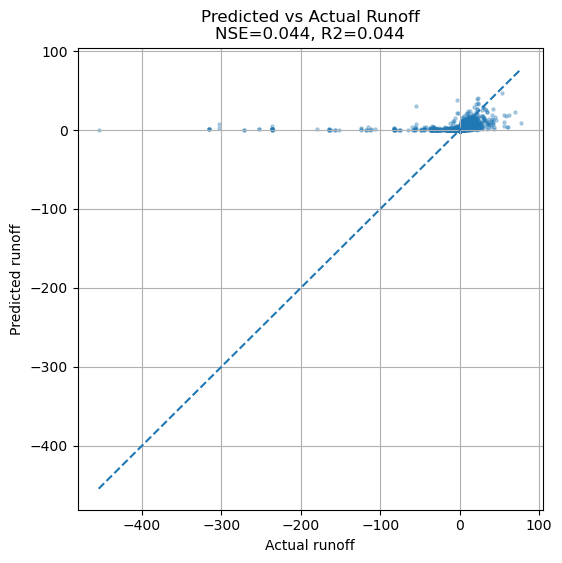

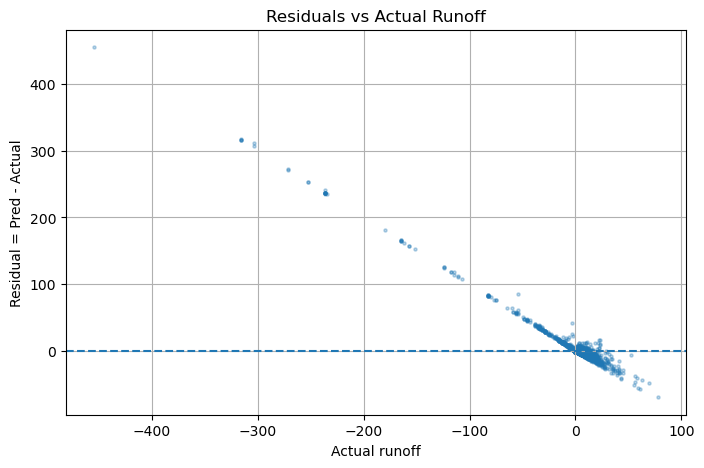

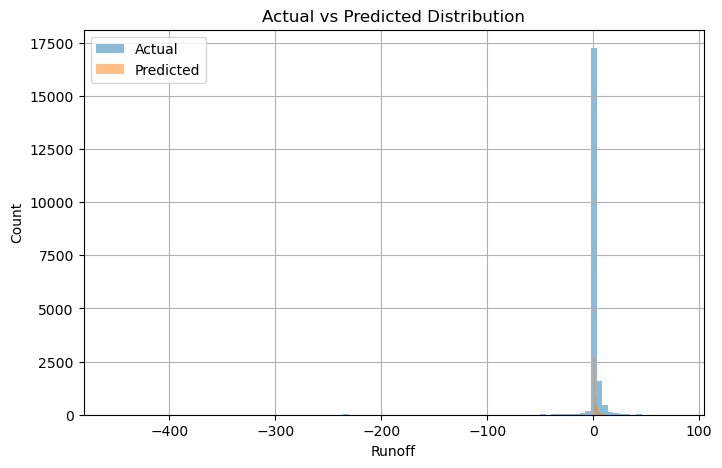

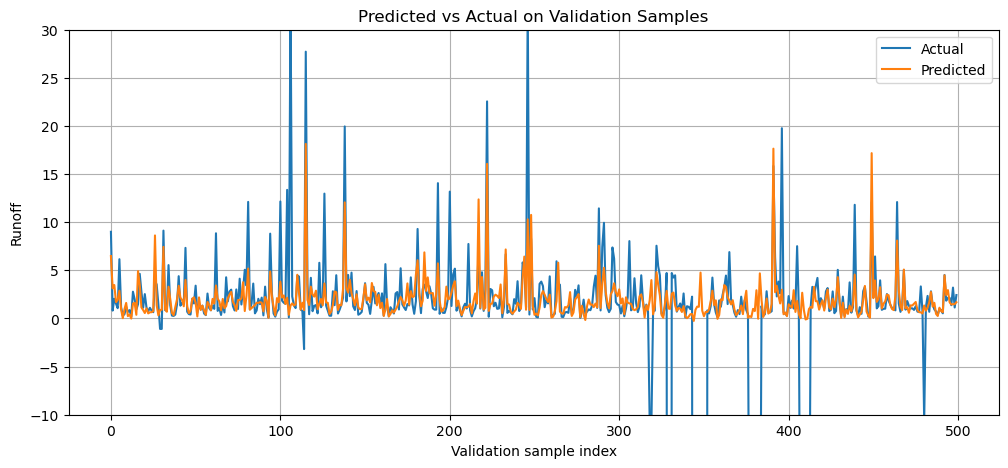

In [49]:
# ======== EVALUATE + VISUALIZE AUTOFORMER PERFORMANCE ========

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        pred = model(x)

        all_preds.append(pred.cpu())
        all_true.append(y.cpu())

pred_norm = torch.cat(all_preds).numpy().reshape(-1)
true_norm = torch.cat(all_true).numpy().reshape(-1)

# Convert back to original runoff scale
pred = pred_norm * dataset.y_std.item() + dataset.y_mean.item()
true = true_norm * dataset.y_std.item() + dataset.y_mean.item()

# ---------- Metrics ----------
mse = mean_squared_error(true, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(true, pred)
r2 = r2_score(true, pred)

nse = 1 - np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2)

print("Validation Performance")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")
print(f"NSE:  {nse:.4f}")

# ---------- Scatter plot ----------
plt.figure(figsize=(6, 6))
plt.scatter(true, pred, s=5, alpha=0.3)
plt.plot([true.min(), true.max()], [true.min(), true.max()], linestyle="--")
plt.xlabel("Actual runoff")
plt.ylabel("Predicted runoff")
plt.title(f"Predicted vs Actual Runoff\nNSE={nse:.3f}, R2={r2:.3f}")
plt.grid(True)
plt.show()

# ---------- Residual plot ----------
residuals = pred - true

plt.figure(figsize=(8, 5))
plt.scatter(true, residuals, s=5, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual runoff")
plt.ylabel("Residual = Pred - Actual")
plt.title("Residuals vs Actual Runoff")
plt.grid(True)
plt.show()

# ---------- Distribution comparison ----------
plt.figure(figsize=(8, 5))
plt.hist(true, bins=100, alpha=0.5, label="Actual")
plt.hist(pred, bins=100, alpha=0.5, label="Predicted")
plt.xlabel("Runoff")
plt.ylabel("Count")
plt.title("Actual vs Predicted Distribution")
plt.legend()
plt.grid(True)
plt.show()

# ---------- Time-like sequence plot ----------
# This is not true chronological validation because random_split was used,
# but it still helps inspect prediction behavior.
n_plot = min(500, len(true))

plt.figure(figsize=(12, 5))
plt.plot(true[:n_plot], label="Actual")
plt.plot(pred[:n_plot], label="Predicted")
plt.xlabel("Validation sample index")
plt.ylabel("Runoff")
plt.title("Predicted vs Actual on Validation Samples")
plt.legend()
plt.grid(True)
plt.ylim([-10, 30])
plt.show()